<a href="https://colab.research.google.com/github/fahim12345c/Deep-Learning/blob/main/Assignment_2010976119.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar100
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, GlobalMaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16,Xception,ResNet50V2,InceptionV3,DenseNet121,EfficientNetB0,MobileNetV2,NASNetMobile,DenseNet169,EfficientNetB1
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# CONFIG
BATCH_SIZE = 32
NUM_CLASSES = 20
IMG_SIZE = (224, 224)
EPOCHS = 10

Display Dataset

In [ ]:
def display_dataet(img_set, title_set):
  n=len(img_set)
  for i in range(n):
    plt.subplot(3, 3, i+1)
    plt.imshow(img_set[i])
    plt.title(title_set[i])
  plt.show()
  plt.close()


Load Dataset

In [ ]:
def get_subset_cifar100(num_classes=20):
  (trainX, trainY), (testX, testY)=cifar100.load_data()
  ttx=[]
  tty=[]
  tsx=[]
  tsy=[]
  for i in range(len(trainY)):
    if trainY[i]<num_classes:
      ttx.append(trainX[i])
      tty.append(trainY[i])

  for i in range(len(testY)):
    if testY[i]<num_classes:
      tsx.append(testX[i])
      tsy.append(testY[i])

  trainX = np.array(ttx)
  trainY = np.array(tty)
  testX = np.array(tsx)
  testY = np.array(tsy)
  print('trainX.shape: {}, trainY.shape: {}, testX.shape: {}, testY.shape: {})'.format(trainX.shape, trainY.shape, testX.shape, testY.shape))
  print('trainX.dtype: {}, trainY.dtype: {}, testX.dtype: {}, testY.dtype: {}'.format(trainX.dtype, trainY.dtype, testX.dtype, testY.dtype))
  print('trainX.Range: {} - {}, testX.Range: {} - {}'.format(trainX.max(), trainX.min(), testX.max(), testX.min()))
  return (trainX, trainY), (testX, testY)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
trainX.shape: (10000, 32, 32, 3), trainY.shape: (10000, 1), testX.shape: (2000, 32, 32, 3), testY.shape: (2000, 1))
trainX.dtype: uint8, trainY.dtype: int64, testX.dtype: uint8, testY.dtype: int64
trainX.Range: 255 - 0, testX.Range: 255 - 0


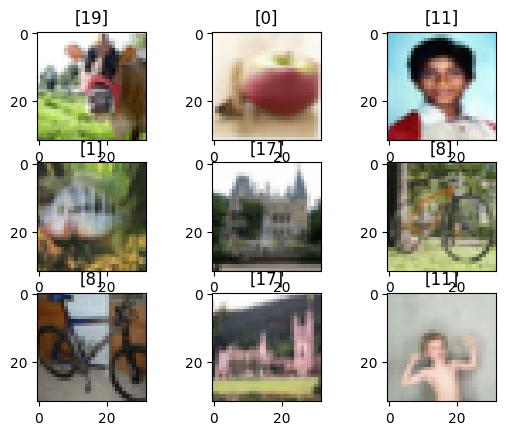

In [ ]:
(trainX,trainY),(testX,testY)=get_subset_cifar100()
display_dataet(trainX[:9],trainY[:9])
trainY = to_categorical(trainY, num_classes=NUM_CLASSES)
testY = to_categorical(testY, num_classes=NUM_CLASSES)

Prepare Dataset

In [ ]:
VAL_SPLIT = 0.2
num_val = int(len(trainX) * VAL_SPLIT)
valX, valY = trainX[:num_val], trainY[:num_val]
trainX, trainY = trainX[num_val:], trainY[num_val:]

In [ ]:
def preprocess_with_model(images, model_type="VGG16"):
    images = tf.image.resize(images, (224, 224))
    images = tf.cast(images, tf.float32)

    if model_type == "VGG16":
        from tensorflow.keras.applications.vgg16 import preprocess_input
    elif model_type == "ResNet50V2":
        from tensorflow.keras.applications.resnet50V2 import preprocess_input
    elif model_type == "InceptionV3":
        from tensorflow.keras.applications.inception_v3 import preprocess_input
        images = tf.image.resize(images, (299, 299))
    elif model_type == "Xception":
        from tensorflow.keras.applications.xception import preprocess_input
        images = tf.image.resize(images, (299, 299))
    elif model_type == "DenseNet121":
        from tensorflow.keras.applications.densenet import preprocess_input
        images = tf.image.resize(images, (224, 224))
    elif model_type == "EfficientNetB0":
        from tensorflow.keras.applications.efficientnet import preprocess_input
        images = tf.image.resize(images, (224, 224))
    elif model_type == "MobileNetv2":
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        images = tf.image.resize(images, (224, 224))
    elif model_type == "NASNetMobile":
        from tensorflow.keras.applications.nasnet import preprocess_input
        images = tf.image.resize(images, (224, 224))
    elif model_type == "DenseNet169":
        from tensorflow.keras.applications.densenet import preprocess_input
        images = tf.image.resize(images, (224, 224))
    elif model_type == "EfficientNetB1":
        from tensorflow.keras.applications.efficientnet import preprocess_input
        images = tf.image.resize(images, (240, 240))
    else:
        preprocess_input = lambda x: x / 255.0  # Normalize [0,1] for custom

    return preprocess_input(images)

In [ ]:
def create_dataset(X, Y, model_type='', shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))

    if shuffle:
        dataset = dataset.shuffle(1024)

    dataset = dataset.map(lambda x, y: (preprocess_with_model(x, model_type), y),
                          num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

#VGG16 pre trained model performance

In [ ]:
train_ds = create_dataset(trainX, trainY,'VGG16',shuffle=True)
val_ds = create_dataset(valX, valY,'VGG16')
test_ds = create_dataset(testX, testY,'VGG16')



base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,851,156 (56.65 MB)

 Trainable params: 136,468 (533.08 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 236ms/step - accuracy: 0.3735 - loss: 10.4051 - val_accuracy: 0.5550 - val_loss: 1.6239
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.6329 - loss: 1.2784 - val_accuracy: 0.6325 - val_loss: 1.2868
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.7646 - loss: 0.7874 - val_accuracy: 0.6880 - val_loss: 1.1337
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 248ms/step - accuracy: 0.8096 - loss: 0.5804 - val_accuracy: 0.7050 - val_loss: 1.1156
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 245ms/step - accuracy: 0.8566 - loss: 0.4326 - val_accuracy: 0.7200 - val_loss: 1.1211
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 249ms/step - accuracy: 0.8762 - loss: 0.3695 - val_accuracy: 0.7240 - val_loss: 1.1576
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.8997 - loss: 0.2976 - val_accuracy: 0.7430 - val_loss: 1.1598
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 249ms/step - accuracy: 0.9264 - loss: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.7409 - loss: 1.2834


#Xecption

In [ ]:
train_ds = create_dataset(trainX, trainY,'Xception',shuffle=True)
val_ds = create_dataset(valX, valY,'Xception')
test_ds = create_dataset(testX, testY,'Xception')



base_model=Xception(weights='imagenet',include_top=False,input_shape=(299,299,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 21,391,164 (81.60 MB)

 Trainable params: 529,684 (2.02 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 122s 403ms/step - accuracy: 0.6340 - loss: 1.3642 - val_accuracy: 0.7895 - val_loss: 0.6408
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 294ms/step - accuracy: 0.8408 - loss: 0.4959 - val_accuracy: 0.8180 - val_loss: 0.5560
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 319ms/step - accuracy: 0.8869 - loss: 0.3448 - val_accuracy: 0.8180 - val_loss: 0.5603
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 293ms/step - accuracy: 0.9112 - loss: 0.2618 - val_accuracy: 0.8120 - val_loss: 0.6048
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 317ms/step - accuracy: 0.9401 - loss: 0.1764 - val_accuracy: 0.8285 - val_loss: 0.6036
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 316ms/step - accuracy: 0.9513 - loss: 0.1381 - val_accuracy: 0.8225 - val_loss: 0.6273
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 319ms/step - accuracy: 0.9596 - loss: 0.1100 - val_accuracy: 0.8260 - val_loss: 0.6486
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 318ms/step - accuracy: 0.9802 - loss: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 0.8548 - loss: 0.6628


#ResNet50V2

In [ ]:
train_ds = create_dataset(trainX, trainY,'Resnet50V2',shuffle=True)
val_ds = create_dataset(valX, valY,'Resnet50V2')
test_ds = create_dataset(testX, testY,'Resnet50V2')


base_model=ResNet50V2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,094,484 (91.91 MB)

 Trainable params: 529,684 (2.02 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.5216 - loss: 3.7599 - val_accuracy: 0.7275 - val_loss: 0.8823
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.7957 - loss: 0.6364 - val_accuracy: 0.7585 - val_loss: 0.8140
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8604 - loss: 0.4213 - val_accuracy: 0.7650 - val_loss: 0.8286
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.9079 - loss: 0.2645 - val_accuracy: 0.7800 - val_loss: 0.7792
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9380 - loss: 0.1776 - val_accuracy: 0.7840 - val_loss: 0.8466
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9645 - loss: 0.1079 - val_accuracy: 0.7800 - val_loss: 0.8963
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.9664 - loss: 0.0924 - val_accuracy: 0.7785 - val_loss: 0.9810
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.9782 - loss: 0.0762 -

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7900 - loss: 1.1677


#InceptionV3

In [ ]:
train_ds = create_dataset(trainX, trainY,'InceptionV3',shuffle=True)
val_ds = create_dataset(valX, valY,'InceptionV3')
test_ds = create_dataset(testX, testY,'InceptionV3')


base_model=InceptionV3(weights='imagenet',include_top=False,input_shape=(299,299,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 149, 149,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,332,468 (85.19 MB)

 Trainable params: 529,684 (2.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 191ms/step - accuracy: 0.4489 - loss: 3.0416 - val_accuracy: 0.7500 - val_loss: 0.8501
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - accuracy: 0.7786 - loss: 0.7217 - val_accuracy: 0.7550 - val_loss: 0.8431
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.8177 - loss: 0.5884 - val_accuracy: 0.7670 - val_loss: 0.7950
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.8503 - loss: 0.4687 - val_accuracy: 0.7730 - val_loss: 0.8162
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - accuracy: 0.8769 - loss: 0.3829 - val_accuracy: 0.7605 - val_loss: 0.8063
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - accuracy: 0.8845 - loss: 0.3426 - val_accuracy: 0.7695 - val_loss: 0.8225
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.8922 - loss: 0.3081 - val_accuracy: 0.7800 - val_loss: 0.8269
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.9187 - loss: 0

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.7866 - loss: 0.8113


#MobileNetV2

In [ ]:
train_ds = create_dataset(trainX, trainY,'MobileNetV2',shuffle=True)
val_ds = create_dataset(valX, valY,'MobileNetV2')
test_ds = create_dataset(testX, testY,'MobileNetV2')


base_model=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,060 (9.88 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.3901 - loss: 3.0841 - val_accuracy: 0.6270 - val_loss: 1.1778
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.7083 - loss: 0.9256 - val_accuracy: 0.6790 - val_loss: 1.0315
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7624 - loss: 0.7220 - val_accuracy: 0.6815 - val_loss: 1.0390
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7967 - loss: 0.6064 - val_accuracy: 0.7125 - val_loss: 0.9438
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.8158 - loss: 0.5289 - val_accuracy: 0.7095 - val_loss: 0.9178
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8650 - loss: 0.4106 - val_accuracy: 0.7255 - val_loss: 0.8942
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8699 - loss: 0.3702 - val_accuracy: 0.7090 - val_loss: 0.9726
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8923 - loss: 0.3227 - val_

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7338 - loss: 0.9645


#DenseNet121

In [ ]:
train_ds = create_dataset(trainX, trainY,'DenseNet121',shuffle=True)
val_ds = create_dataset(valX, valY,'DenseNet121')
test_ds = create_dataset(testX, testY,'DenseNet121')


base_model=DenseNet121(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,305,044 (27.87 MB)

 Trainable params: 267,540 (1.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 261ms/step - accuracy: 0.5261 - loss: 1.9078 - val_accuracy: 0.7560 - val_loss: 0.7377
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step - accuracy: 0.8156 - loss: 0.5623 - val_accuracy: 0.7935 - val_loss: 0.6648
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.8708 - loss: 0.3930 - val_accuracy: 0.8120 - val_loss: 0.5761
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 119ms/step - accuracy: 0.8940 - loss: 0.3102 - val_accuracy: 0.7940 - val_loss: 0.7044
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step - accuracy: 0.9056 - loss: 0.2785 - val_accuracy: 0.8135 - val_loss: 0.6148
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9206 - loss: 0.2359 - val_accuracy: 0.8040 - val_loss: 0.6441
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9272 - loss: 0.2059 - val_accuracy: 0.8240 - val_loss: 0.6184
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.9546 - loss: 0.1

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8166 - loss: 0.7439


#EfficentNetB0

In [ ]:
train_ds = create_dataset(trainX, trainY,'EfficientNetB0',shuffle=True)
val_ds = create_dataset(valX, valY,'EfficientNetB0')
test_ds = create_dataset(testX, testY,'EfficientNetB0')


base_model=EfficientNetB0(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,382,647 (16.72 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.5524 - loss: 1.8609 - val_accuracy: 0.7900 - val_loss: 0.6841
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8125 - loss: 0.5900 - val_accuracy: 0.8105 - val_loss: 0.5783
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.8529 - loss: 0.4519 - val_accuracy: 0.8155 - val_loss: 0.6191
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.8789 - loss: 0.3634 - val_accuracy: 0.8155 - val_loss: 0.6078
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.8973 - loss: 0.3025 - val_accuracy: 0.8160 - val_loss: 0.6286
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9077 - loss: 0.2729 - val_accuracy: 0.8325 - val_loss: 0.5736
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9070 - loss: 0.2709 - val_accuracy: 0.8220 - val_loss: 0.6271
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9294 - loss: 0.2140 - 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8346 - loss: 0.6170


#NASNetMobile

In [ ]:
train_ds = create_dataset(trainX, trainY,'NASNetMobile',shuffle=True)
val_ds = create_dataset(valX, valY,'NASNetMobile')
test_ds = create_dataset(testX, testY,'NASNetMobile')


base_model=NASNetMobile(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn1            │ (None, 111, 111,  │        128 │ stem_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_conv_1_s… │ (None, 111, 111,  │        352 │ activation_94[0]… │
│ (Conv2D)            │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_bn_1_ste… │ (None, 111, 111,  │         44 │ reduction_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 111, 111,  │          0 │ reduction_bn_1_s… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 115, 115,  │          0 │ activation_95[0]… │
│ (ZeroPadding2D)     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 117, 117,  │          0 │ activation_97[0]… │
│ (ZeroPadding2D)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │        396 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │      1,920 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_2_r… │ (None, 56, 56,    │        396 │ activation_96[0]

 Total params: 4,545,448 (17.34 MB)

 Trainable params: 275,732 (1.05 MB)

 Non-trainable params: 4,269,716 (16.29 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 169ms/step - accuracy: 0.5766 - loss: 1.9012 - val_accuracy: 0.7405 - val_loss: 0.8322
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.7998 - loss: 0.6415 - val_accuracy: 0.7530 - val_loss: 0.8466
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step - accuracy: 0.8435 - loss: 0.4803 - val_accuracy: 0.7705 - val_loss: 0.7587
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.8622 - loss: 0.3985 - val_accuracy: 0.7875 - val_loss: 0.7337
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step - accuracy: 0.8850 - loss: 0.3219 - val_accuracy: 0.7735 - val_loss: 0.7380
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.9073 - loss: 0.2700 - val_accuracy: 0.7835 - val_loss: 0.7268
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.9240 - loss: 0.2183 - val_accuracy: 0.7690 - val_loss: 0.8265
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.9443 - loss: 0.1634 -

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8105 - loss: 0.7268


#DenseNet169

In [ ]:
train_ds = create_dataset(trainX, trainY,'DenseNet169',shuffle=True)
val_ds = create_dataset(valX, valY,'DenseNet169')
test_ds = create_dataset(testX, testY,'DenseNet169')


base_model=DenseNet169(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, 230, 230,  │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_6… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_7… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 13,074,260 (49.87 MB)

 Trainable params: 431,380 (1.65 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 280ms/step - accuracy: 0.5779 - loss: 1.7335 - val_accuracy: 0.7875 - val_loss: 0.6697
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.8451 - loss: 0.4973 - val_accuracy: 0.8115 - val_loss: 0.6136
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 117ms/step - accuracy: 0.8850 - loss: 0.3427 - val_accuracy: 0.8215 - val_loss: 0.6273
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9099 - loss: 0.2588 - val_accuracy: 0.8140 - val_loss: 0.6575
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 139ms/step - accuracy: 0.9274 - loss: 0.2046 - val_accuracy: 0.8190 - val_loss: 0.6589
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.9504 - loss: 0.1377 - val_accuracy: 0.8355 - val_loss: 0.5982
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 121ms/step - accuracy: 0.9649 - loss: 0.1032 - val_accuracy: 0.8405 - val_loss: 0.6513
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 143ms/step - accuracy: 0.9765 - loss: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8415 - loss: 0.6762


#EfficientNetB1

In [ ]:
train_ds = create_dataset(trainX, trainY,'EfficientNetB1',shuffle=True)
val_ds = create_dataset(valX, valY,'EfficientNetB1')
test_ds = create_dataset(testX, testY,'EfficientNetB1')


base_model=EfficientNetB1(weights='imagenet',include_top=False,input_shape=(240,240,3))
base_model.trainable=False
x=GlobalMaxPooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
output=Dense(20,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_10[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,908,315 (26.35 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 6,575,239 (25.08 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 155ms/step - accuracy: 0.5349 - loss: 2.2429 - val_accuracy: 0.7885 - val_loss: 0.7208
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 79ms/step - accuracy: 0.8124 - loss: 0.6075 - val_accuracy: 0.8145 - val_loss: 0.6080
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.8244 - loss: 0.5128 - val_accuracy: 0.8410 - val_loss: 0.5080
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8652 - loss: 0.4040 - val_accuracy: 0.8490 - val_loss: 0.4867
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.8975 - loss: 0.3317 - val_accuracy: 0.8445 - val_loss: 0.4998
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9065 - loss: 0.2811 - val_accuracy: 0.8150 - val_loss: 0.6347
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.8989 - loss: 0.2939 - val_accuracy: 0.8385 - val_loss: 0.5754
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9156 - loss: 0.2476 -

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8428 - loss: 0.6045
